In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('/content/drive/MyDrive/Data set/Credit Card Dataset for Clustering.csv')
print("Shape:", df.shape)
df.head()

Shape: (8950, 18)


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [4]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [5]:
df.isnull().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


In [6]:
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())

In [7]:
df.isnull().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df_cluster = df.drop('CUST_ID', axis=1)
df_cluster.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,312.343947,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


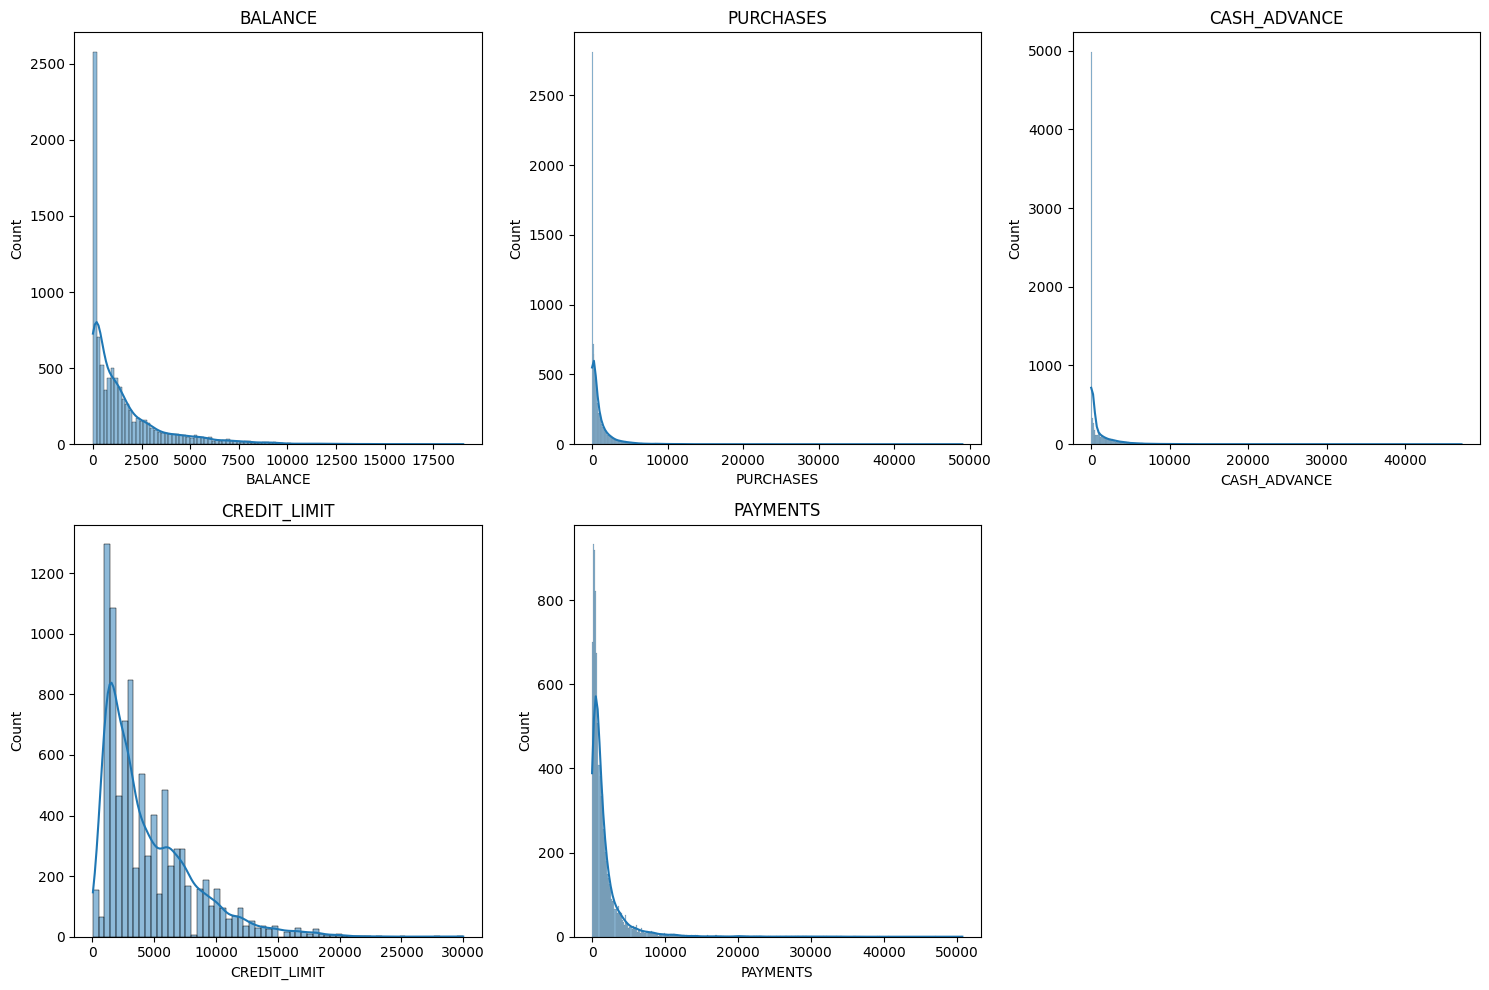

In [12]:
plt.figure(figsize=(15,10))
cols_to_plot = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS']

for i, col in enumerate(cols_to_plot):
    plt.subplot(2, 3, i+1)
    sns.histplot(df_cluster[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

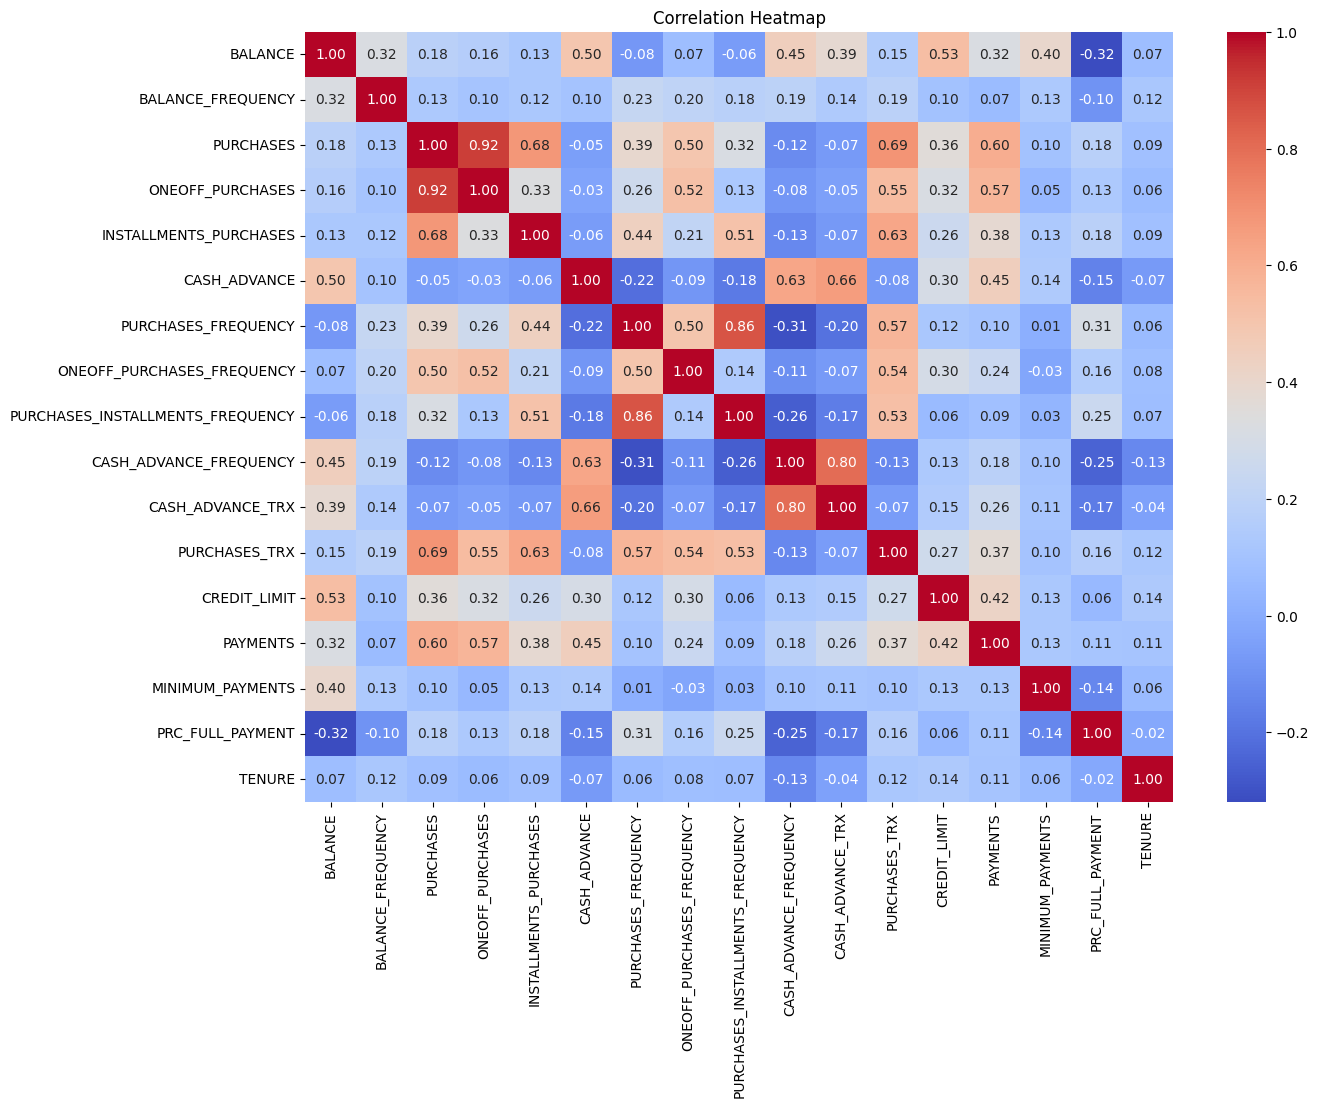

In [13]:
plt.figure(figsize=(14,10))
sns.heatmap(df_cluster.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [14]:
df_cluster.skew().sort_values(ascending=False)

,0
MINIMUM_PAYMENTS,13.852446
ONEOFF_PURCHASES,10.045083
PURCHASES,8.144269
INSTALLMENTS_PURCHASES,7.299120
PAYMENTS,5.907620
CASH_ADVANCE_TRX,5.721298
CASH_ADVANCE,5.166609
PURCHASES_TRX,4.630655
BALANCE,2.393386
PRC_FULL_PAYMENT,1.942820


In [16]:
cols_to_log = ['BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES',
               'CASH_ADVANCE', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'PAYMENTS',
               'MINIMUM_PAYMENTS', 'CREDIT_LIMIT']

df_log = df_cluster.copy()

for col in cols_to_log:
    df_log[col] = np.log1p(df_log[col])

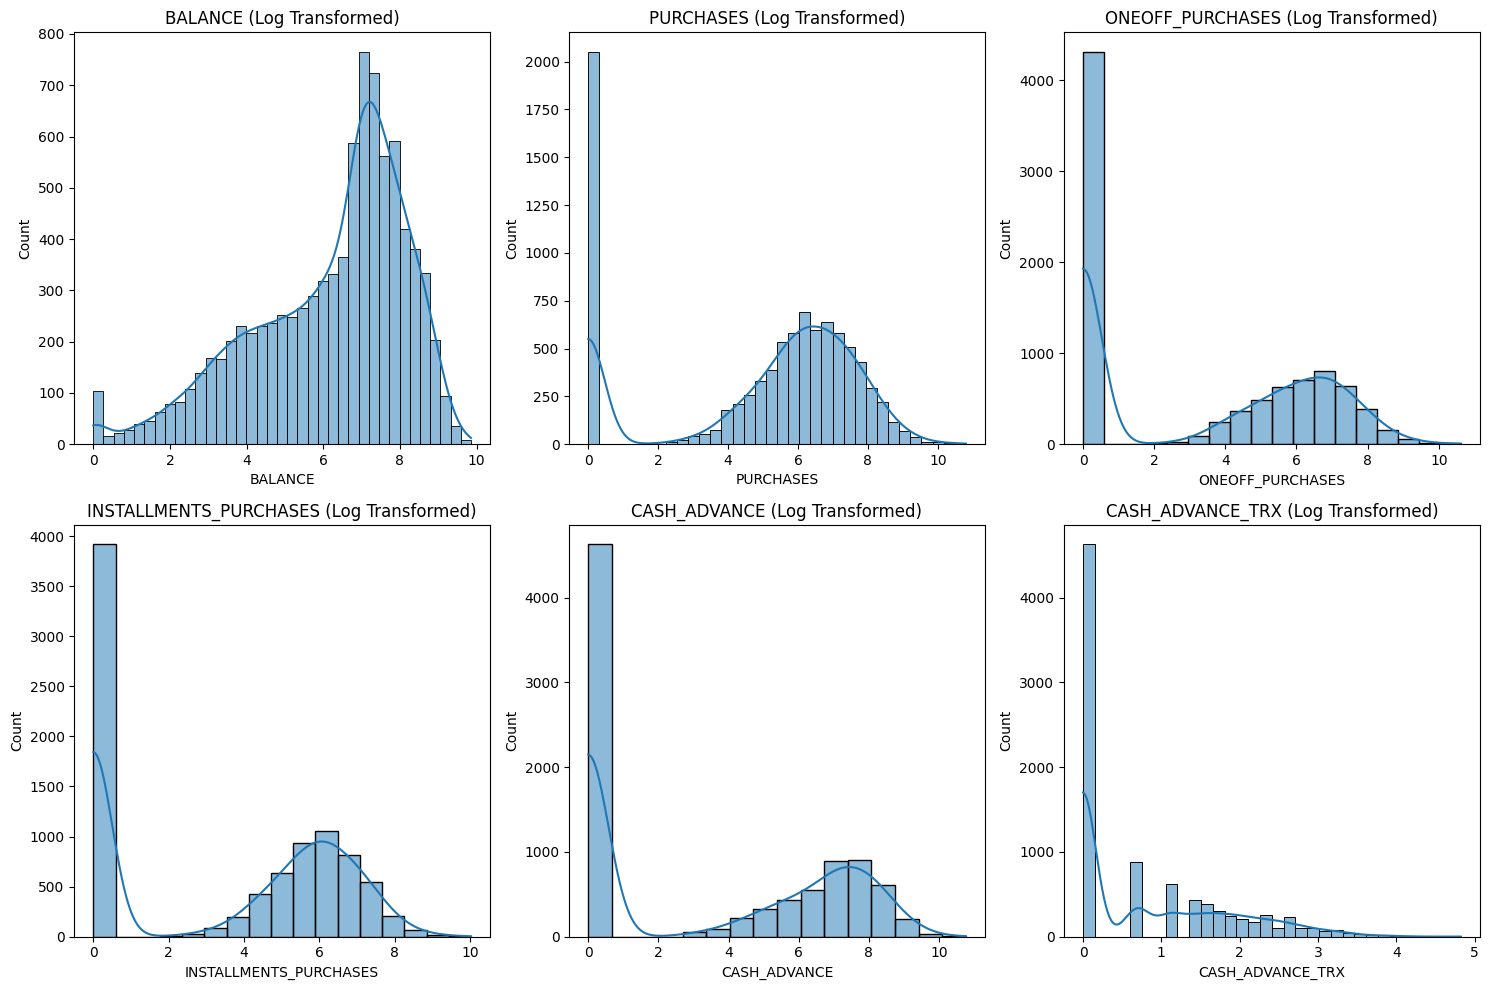

In [17]:
plt.figure(figsize=(15,10))
for i, col in enumerate(cols_to_log[:6]):
    plt.subplot(2, 3, i+1)
    sns.histplot(df_log[col], kde=True)
    plt.title(f'{col} (Log Transformed)')

plt.tight_layout()
plt.show()

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_log)

df_scaled = pd.DataFrame(scaled_data, columns=df_log.columns)
df_scaled.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-1.205218,-0.249434,-0.113532,-0.987090,0.394480,-0.930733,-0.806490,-0.678661,-0.707313,-0.675349,-0.810069,-0.579510,-1.447163,-0.824484,-0.829841,-0.525551,0.36068
1,0.948918,0.134325,-1.679855,-0.987090,-1.087454,1.528788,-1.221758,-0.678661,-0.916995,0.573963,0.784603,-1.379210,0.926060,1.065033,0.908184,0.234227,0.36068
2,0.824993,0.518084,0.600727,1.062022,-1.087454,-0.930733,1.269843,2.673451,-0.916995,-0.675349,-0.810069,0.487865,1.010229,-0.119300,0.450407,-0.525551,0.36068
3,0.624653,-1.016953,0.827499,1.265778,-1.087454,0.564372,-1.014125,-0.399319,-0.916995,-0.258913,-0.123281,-0.874655,1.010229,-4.161996,-0.144271,-0.525551,0.36068
4,0.271260,0.518084,-0.708481,-0.114307,-1.087454,-0.930733,-1.014125,-0.399319,-0.916995,-0.675349,-0.810069,-0.874655,-1.224909,-0.064979,-0.351833,-0.525551,0.36068


In [19]:
df_scaled.describe().loc[['mean', 'std']]

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
mean,0.000000,1.587805e-16,6.986342e-17,0.000000,1.026119e-16,6.668781e-17,9.328354e-17,1.905366e-17,5.716098e-17,-1.595744e-16,-7.383293e-17,1.397268e-16,-5.462049e-16,3.620195e-16,-2.159415e-16,-9.526830e-18,2.921561e-16
std,1.000056,1.000056e+00,1.000056e+00,1.000056,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00


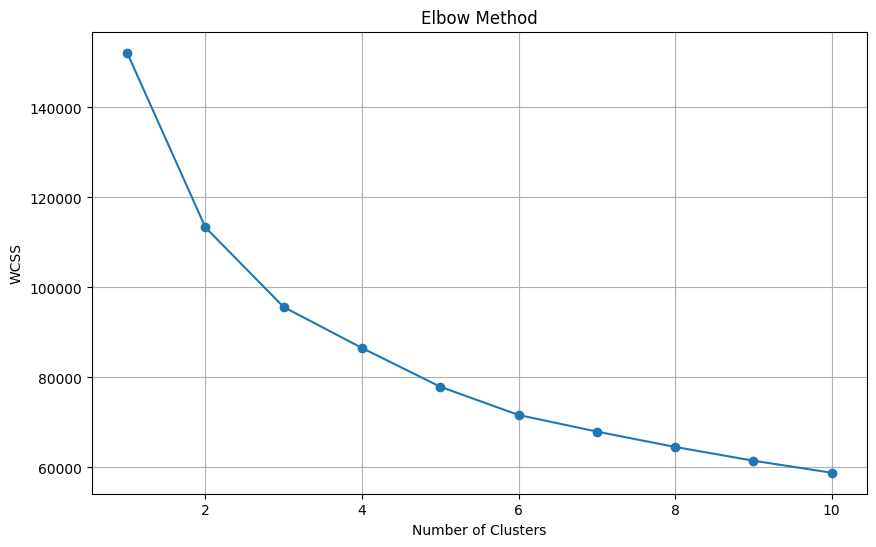

In [20]:
from sklearn.cluster import KMeans

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10,6))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.grid(True)
plt.show()

Clusters: 2, Silhouette Score: 0.2515
Clusters: 3, Silhouette Score: 0.2244
Clusters: 4, Silhouette Score: 0.2166
Clusters: 5, Silhouette Score: 0.2183
Clusters: 6, Silhouette Score: 0.2172
Clusters: 7, Silhouette Score: 0.2204
Clusters: 8, Silhouette Score: 0.2100
Clusters: 9, Silhouette Score: 0.1805
Clusters: 10, Silhouette Score: 0.1817


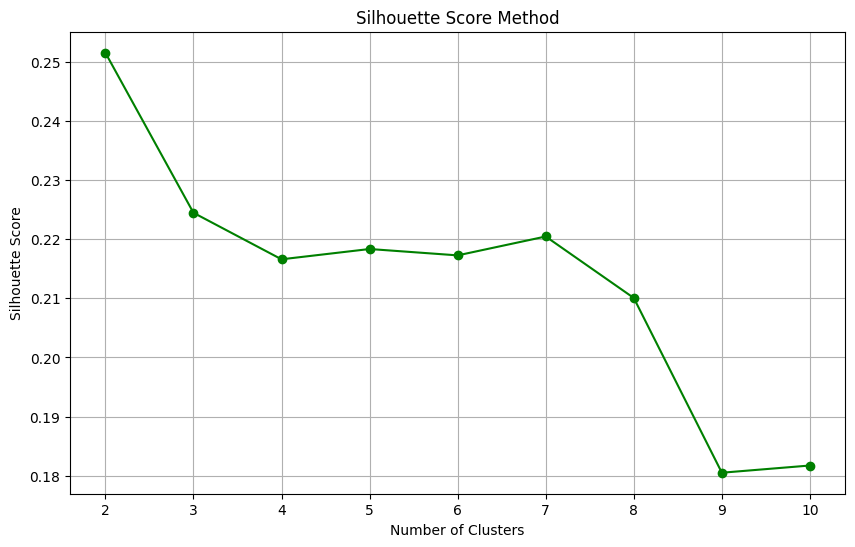

In [21]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, labels)
    silhouette_scores.append(score)
    print(f"Clusters: {i}, Silhouette Score: {score:.4f}")

plt.figure(figsize=(10,6))
plt.plot(range(2,11), silhouette_scores, marker='o', color='green')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score Method')
plt.grid(True)
plt.show()

In [22]:
kmeans_final = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(df_scaled)

df_cluster['Cluster'] = cluster_labels

df_cluster.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,0
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,1
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,2
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,312.343947,0.000000,12,0
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,0


In [23]:
df_cluster['Cluster'].value_counts().sort_index()

,count
Cluster,
0,1570
1,2760
2,2580
3,2040


/tmp/ipykernel_589/51362742.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Cluster', data=df_cluster, palette='viridis')


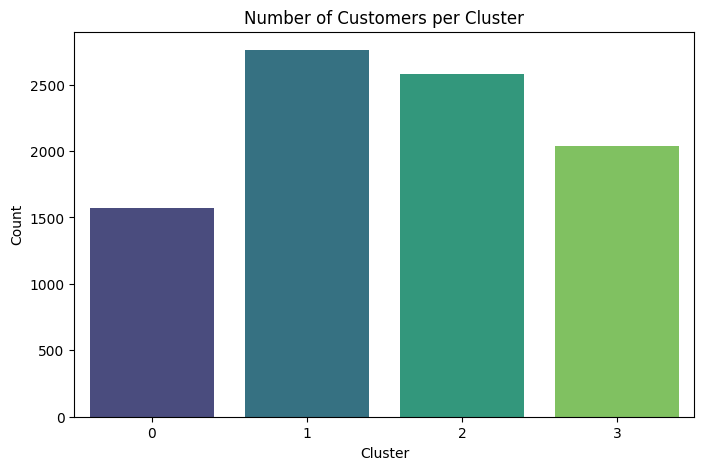

In [24]:
plt.figure(figsize=(8,5))
sns.countplot(x='Cluster', data=df_cluster, palette='viridis')
plt.title('Number of Customers per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.show()

In [25]:
cluster_summary = df_cluster.groupby('Cluster').mean()
cluster_summary

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,213.575602,0.529012,351.391924,271.262350,80.500115,113.630403,0.253524,0.113797,0.133932,0.021075,0.361146,3.927389,3561.169851,742.552906,189.746891,0.162090,11.334395
1,2460.811226,0.939872,103.316315,79.457924,23.902475,2220.058908,0.074203,0.042242,0.029560,0.303287,7.368116,1.207246,4364.174352,1818.290716,1123.096868,0.030980,11.391667
2,2243.725833,0.978487,2604.153267,1751.804353,852.412926,862.924518,0.824089,0.554666,0.547056,0.114079,2.865116,35.468605,6393.232636,2933.028379,1090.310123,0.170587,11.812791
3,532.394305,0.932589,697.612490,67.388961,631.114735,112.151413,0.813556,0.042014,0.763946,0.022087,0.383333,15.022549,2986.828456,862.810696,662.385034,0.291984,11.454412


In [26]:
key_cols = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT',
            'PAYMENTS', 'PURCHASES_FREQUENCY', 'CASH_ADVANCE_FREQUENCY',
            'PRC_FULL_PAYMENT', 'TENURE']

cluster_summary[key_cols].round(2)

,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,
0,213.58,351.39,113.63,3561.17,742.55,0.25,0.02,0.16,11.33
1,2460.81,103.32,2220.06,4364.17,1818.29,0.07,0.30,0.03,11.39
2,2243.73,2604.15,862.92,6393.23,2933.03,0.82,0.11,0.17,11.81
3,532.39,697.61,112.15,2986.83,862.81,0.81,0.02,0.29,11.45


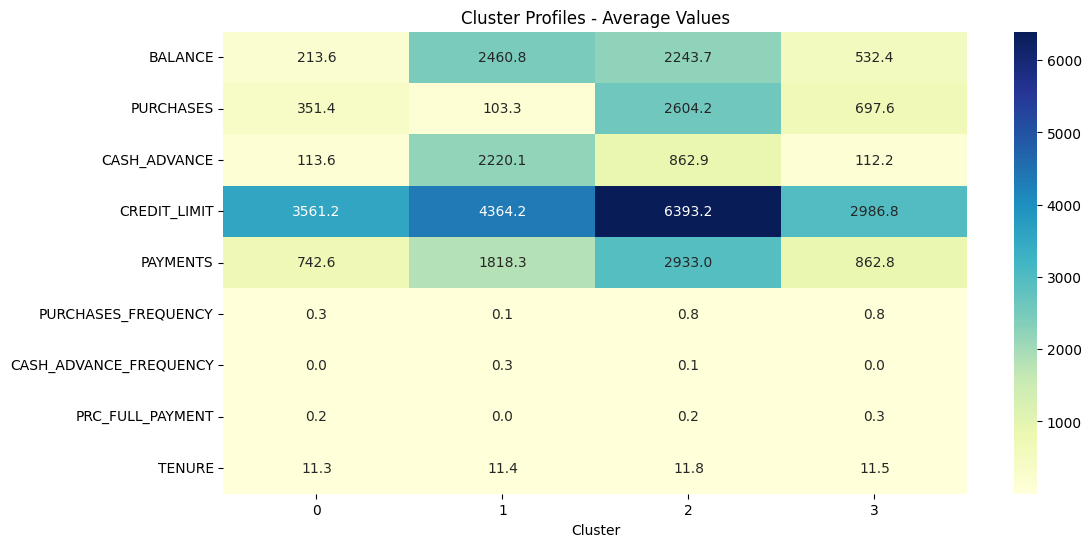

In [27]:
plt.figure(figsize=(12,6))
sns.heatmap(cluster_summary[key_cols].T, annot=True, cmap='YlGnBu', fmt='.1f')
plt.title('Cluster Profiles - Average Values')
plt.xlabel('Cluster')
plt.show()

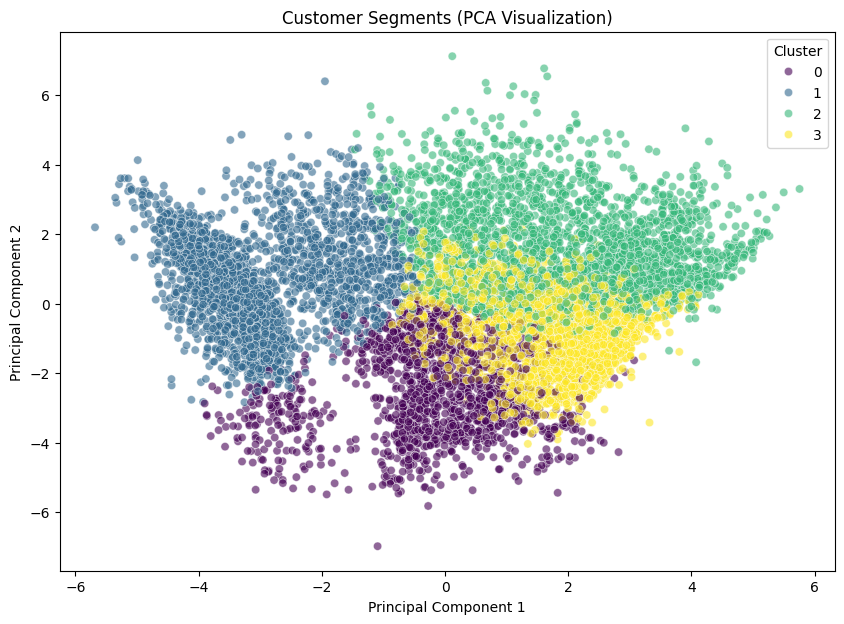

In [28]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scaled)

plt.figure(figsize=(10,7))
sns.scatterplot(x=pca_result[:,0], y=pca_result[:,1], hue=df_cluster['Cluster'], palette='viridis', alpha=0.6)
plt.title('Customer Segments (PCA Visualization)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

In [29]:
print(kmeans_final)

KMeans(n_clusters=4, n_init=10, random_state=42)


In [30]:
import numpy as np
new_customer = pd.DataFrame({
    'BALANCE': [2500],
    'BALANCE_FREQUENCY': [1.0],
    'PURCHASES': [3000],
    'ONEOFF_PURCHASES': [2000],
    'INSTALLMENTS_PURCHASES': [1000],
    'CASH_ADVANCE': [0],
    'PURCHASES_FREQUENCY': [0.9],
    'ONEOFF_PURCHASES_FREQUENCY': [0.6],
    'PURCHASES_INSTALLMENTS_FREQUENCY': [0.5],
    'CASH_ADVANCE_FREQUENCY': [0.0],
    'CASH_ADVANCE_TRX': [0],
    'PURCHASES_TRX': [20],
    'CREDIT_LIMIT': [7000],
    'PAYMENTS': [3200],
    'MINIMUM_PAYMENTS': [500],
    'PRC_FULL_PAYMENT': [0.3],
    'TENURE': [12]
})

new_customer_log = new_customer.copy()
for col in cols_to_log:
    new_customer_log[col] = np.log1p(new_customer_log[col])
new_customer_scaled = scaler.transform(new_customer_log)
predicted_cluster = kmeans_final.predict(new_customer_scaled)
print(f"Yeh customer Cluster {predicted_cluster[0]} mein aata hai")

Yeh customer Cluster 2 mein aata hai


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [31]:
for cluster_num in range(4):
    print(f"\n--- Cluster {cluster_num} Sample Customers ---")
    print(df_cluster[df_cluster['Cluster'] == cluster_num][['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT']].sample(3))


--- Cluster 0 Sample Customers ---
         BALANCE  PURCHASES  CASH_ADVANCE  CREDIT_LIMIT
808   155.924331     517.14           0.0        3000.0
6775   12.423324      21.99           0.0        4000.0
215     2.433254      36.00           0.0        7500.0

--- Cluster 1 Sample Customers ---
          BALANCE  PURCHASES  CASH_ADVANCE  CREDIT_LIMIT
825   1892.439622      86.70     92.435934        2000.0
5956  1636.518315     542.47   1869.646314        3000.0
4750  2669.587009       0.00    967.482287        6500.0

--- Cluster 2 Sample Customers ---
          BALANCE  PURCHASES  CASH_ADVANCE  CREDIT_LIMIT
4763  1723.804529    3145.79       0.00000        6000.0
5290  1102.632150    1409.31       0.00000        8500.0
8183  1333.899916     356.77    1107.81888        3500.0

--- Cluster 3 Sample Customers ---
          BALANCE  PURCHASES  CASH_ADVANCE  CREDIT_LIMIT
6999    72.025683     891.28      0.000000       10000.0
4527  1238.140283      56.38      0.000000        1600.0
8659 

In [33]:
from google.colab import files
import joblib
joblib.dump(kmeans_final, 'kmeans_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(cols_to_log, 'log_columns.pkl')
files.download('kmeans_model.pkl')
files.download('scaler.pkl')
files.download('log_columns.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>